# 02 · Embeddings — ids to meaning vectors

A token id is just a label (`4806`). It carries no meaning by itself. We look it up in an
**embedding table** to get a vector of numbers = a **coordinate in "meaning space"**.

Words with similar meaning land near each other (`cat` near `dog`, far from `truck`). These
vectors are **learned** during training — the model discovers the geometry itself.

In [3]:
import numpy as np
np.random.seed(0)

VOCAB, D_MODEL = 50, 8                 # tiny demo: 50-word vocab, 8-dim vectors (real: 50k x 4096)
embedding_table = np.random.randn(VOCAB, D_MODEL)

print(embedding_table)

tokens = [7, 12, 3, 0]                 # a sequence of 4 token ids
X = embedding_table[tokens]            # table lookup -> (seq_len, d_model)
print("looked up", len(tokens), "tokens -> shape", X.shape, "= (seq_len, d_model)")
assert X.shape == (4, D_MODEL)

[[ 1.76405235  0.40015721  0.97873798  2.2408932   1.86755799 -0.97727788
   0.95008842 -0.15135721]
 [-0.10321885  0.4105985   0.14404357  1.45427351  0.76103773  0.12167502
   0.44386323  0.33367433]
 [ 1.49407907 -0.20515826  0.3130677  -0.85409574 -2.55298982  0.6536186
   0.8644362  -0.74216502]
 [ 2.26975462 -1.45436567  0.04575852 -0.18718385  1.53277921  1.46935877
   0.15494743  0.37816252]
 [-0.88778575 -1.98079647 -0.34791215  0.15634897  1.23029068  1.20237985
  -0.38732682 -0.30230275]
 [-1.04855297 -1.42001794 -1.70627019  1.9507754  -0.50965218 -0.4380743
  -1.25279536  0.77749036]
 [-1.61389785 -0.21274028 -0.89546656  0.3869025  -0.51080514 -1.18063218
  -0.02818223  0.42833187]
 [ 0.06651722  0.3024719  -0.63432209 -0.36274117 -0.67246045 -0.35955316
  -0.81314628 -1.7262826 ]
 [ 0.17742614 -0.40178094 -1.63019835  0.46278226 -0.90729836  0.0519454
   0.72909056  0.12898291]
 [ 1.13940068 -1.23482582  0.40234164 -0.68481009 -0.87079715 -0.57884966
  -0.31155253  0.056

### Visual: meaning is geometry

Real embeddings are learned, but to *see* the idea we'll hand-place five words in a 2-D
meaning space and measure **cosine similarity** (angle between vectors). Similar meaning →
small angle → high similarity.

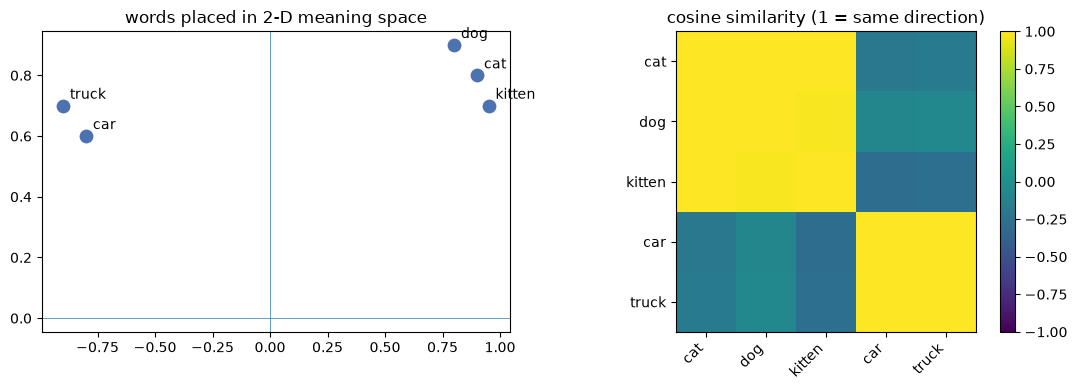

cat vs dog  : 0.99 (high - both animals)
cat vs truck: -0.18 (low  - animal vs vehicle)


In [2]:
import matplotlib.pyplot as plt
import numpy as np

words = ["cat", "dog", "kitten", "car", "truck"]
vecs = np.array([
    [ 0.9,  0.8],   # cat
    [ 0.8,  0.9],   # dog     -> near cat/kitten (animals)
    [ 0.95, 0.7],   # kitten
    [-0.8,  0.6],   # car     -> far from animals (vehicles)
    [-0.9,  0.7],   # truck
])

def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

sim = np.array([[cosine(a, b) for b in vecs] for a in vecs])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(vecs[:, 0], vecs[:, 1], s=80, color="#4C72B0")
for wd, (xx, yy) in zip(words, vecs):
    ax1.annotate(wd, (xx, yy), xytext=(5, 5), textcoords="offset points")
ax1.set_title("words placed in 2-D meaning space"); ax1.axhline(0, lw=.5); ax1.axvline(0, lw=.5)

im = ax2.imshow(sim, cmap="viridis", vmin=-1, vmax=1)
ax2.set_xticks(range(len(words))); ax2.set_xticklabels(words, rotation=45, ha="right")
ax2.set_yticks(range(len(words))); ax2.set_yticklabels(words)
ax2.set_title("cosine similarity (1 = same direction)")
fig.colorbar(im, ax=ax2)
plt.tight_layout(); plt.show()

print("cat vs dog  :", round(cosine(vecs[0], vecs[1]), 2), "(high - both animals)")
print("cat vs truck:", round(cosine(vecs[0], vecs[4]), 2), "(low  - animal vs vehicle)")

**Takeaway.** Embedding = id → vector. Meaning becomes **distance/angle** in a high-dim
space, and it's learned. But so far the model sees a *bag* of vectors with no order — fix that
next: **03 · positional encoding**.